# LDPC Factor Graph Representation

## Project Overview

This project constructs and analyzes factor graph representations of Low-Density Parity-Check (LDPC) codes.

The objective is to model the probabilistic structure of an LDPC code by combining:
- transmitted bit variables,
- noisy channel-output variables,
- parity-check constraints,
- and binary symmetric channel likelihood factors.

The project also studies how the complexity of exact inference scales with the code size by analyzing the treewidth of the associated graphical model.

## Learning goals
- Represent an LDPC code as a **factor graph** with:
  - binary **variable nodes** (bits),
  - **parity-check factors** (XOR constraints),
  - **channel factors** connecting each transmitted bit to its channel output.
- Validate the graph:
  - **structurally**: degrees, factor arities, correct wiring,
  - **semantically**: parity-check factors behave correctly on a known satisfying assignment.

## Implementations
1. a parity-check factor constructor,
2. a channel factor constructor,
3. the factor-graph construction from $H$,
4. graph validation checks and visualization,
5. treewidth scaling analysis.

In [ ]:
# Colab setup
!pip -q install pgmpy networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 12.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import itertools
import networkx as nx

from pgmpy.models import FactorGraph
from pgmpy.factors.discrete import DiscreteFactor

import matplotlib.pyplot as plt
import networkx as nx
from pgmpy.models import FactorGraph

from networkx.algorithms.approximation import treewidth_min_fill_in

# Factor graphs for Low-Density Parity-Check (LDPC) decoding

## Variables and factorization

The task is to transmit $N$ bits over a noisy channel. LDPC codes introduce $M$
parity-check constraints to enable error correction.

The factor graph contains two types of binary variables:
- **transmitted bits**: $x_0,\dots,x_{N-1}$
- **channel outputs**: $y_0,\dots,y_{N-1}$

The joint distribution defined by the factor graph factorizes as
$$
p(x,y)
\;\propto\;
\prod_{m=1}^M \psi_m\bigl(x_{N(m)}\bigr)
\;\;
\prod_{n=0}^{N-1} \phi_n(x_n, y_n),
$$

where $N(m)$ denotes the set of transmitted-bit indices that appear in factor
$\psi_m$, and:
- $\psi_m$ are **parity-check factors** enforcing local constraints on transmitted bits,
- $\phi_n$ are **channel factors** modeling the noise affecting each bit.

## Parity-check factors $\psi_m(x_{N(m)})$

Each parity-check factor enforces an even-parity constraint on a small subset of
transmitted bits.

Formally, the factor is defined as
$$
\psi_m\bigl(x_{N(m)}\bigr)
\;=\;
\begin{cases}
1 & \text{if } \sum_{n \in N(m)} x_n \equiv 0 \pmod 2, \\
0 & \text{otherwise}.
\end{cases}
$$

Thus, each parity-check factor is a **local constraint** that involves only the
$k$ transmitted-bit variables connected to it.

## Channel factors $\phi_n(x_n,y_n)$

Each channel factor connects a transmitted bit $x_n$ to its corresponding channel
output $y_n$.

We model the channel as a **binary symmetric channel (BSC)** with flip probability
$f$, defining
$$
\phi_n(x_n,y_n)
=
p(y_n \mid x_n)
=
\begin{cases}
1-f & \text{if } y_n = x_n, \\
f   & \text{if } y_n \neq x_n.
\end{cases}
$$

Channel factors are independent across bit positions.

## Decoding as inference

In a communication scenario, the channel outputs
$y_0,\dots,y_{N-1}$ are observed.

Decoding consists of inferring the transmitted bits
$x_0,\dots,x_{N-1}$ given these observations, that is, computing the posterior
distribution $p(x \mid y)$.

In the next session, you will approximate this posterior using belief propagation on the same factor graph, after introducing evidence on the $y$ variables.

## 1. LDPC Parity-Check Matrix Generation

An LDPC code is defined by a sparse binary parity-check matrix:

$$
H \in \{0,1\}^{M \times N}
$$

where:

- $N$ is the number of transmitted bits,
- $M$ is the number of parity-check constraints,
- each row represents one parity-check equation,
- each column represents one transmitted bit.

For a regular $(j,k)$-LDPC code:

- each column contains exactly $j$ ones,
- each row contains exactly $k$ ones.

This means that each transmitted bit participates in $j$ parity checks, and each parity check involves $k$ bits.

In this project, we generate a random regular LDPC matrix and use it to define the structure of the factor graph.

In [ ]:
def generate_regular_ldpc_H(N: int, j: int, k: int, seed: int = 0, max_tries: int = 2000) -> np.ndarray:
    """Generate a random (j,k)-regular binary parity-check matrix H of shape (M,N),
    where M = N*j/k must be an integer.

    Notes:
    - This construction is intentionally simple (sufficient for the lab).
    - It may create short cycles; that's fine (Lab 2 is loopy).
    """
    rng = np.random.default_rng(seed)
    if (N * j) % k != 0:
        raise ValueError(f"Need M = N*j/k integer, but N*j={N*j} not divisible by k={k}.")
    M = (N * j) // k

    for _ in range(max_tries):
        # Create j "stubs" per column
        col_stubs = np.repeat(np.arange(N), j)
        rng.shuffle(col_stubs)

        # Assign stubs into M groups of size k (rows)
        H = np.zeros((M, N), dtype=np.uint8)
        ok = True
        for m in range(M):
            cols = col_stubs[m * k : (m + 1) * k]
            # avoid duplicate variable in a single check (keeps row weight exactly k)
            if len(set(cols.tolist())) != k:
                ok = False
                break
            H[m, cols] = 1
        if not ok:
            continue

        # Verify regularity
        if np.all(H.sum(axis=0) == j) and np.all(H.sum(axis=1) == k):
            return H

    raise RuntimeError("Failed to construct a regular LDPC matrix. Try a different seed or parameters.")

In [ ]:
#Example: 
N = 24
j = 3
k = 6
seed_H = 0

H = generate_regular_ldpc_H(N=N, j=j, k=k, seed=seed_H)
M = H.shape[0]
print(H)

print("H shape:", H.shape)
print("column weights (should all be j):", np.unique(H.sum(axis=0)))
print("row weights (should all be k):", np.unique(H.sum(axis=1)))

[[1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1]
 [0 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0]
 [0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0]
 [0 1 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0]
 [0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0]
 [0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 1 0]
 [1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 1 0]]
H shape: (12, 24)
column weights (should all be j): [3]
row weights (should all be k): [6]


## 2. Factor Construction

The LDPC graphical model contains two main types of factors:

### Parity-check factors

Each row of the parity-check matrix defines a constraint on a subset of transmitted bits.

A parity-check factor is equal to 1 when the connected bits satisfy an even parity condition:

$$
\sum_{i \in N(m)} x_i \equiv 0 \pmod{2}
$$

and equal to 0 otherwise.

Here, $N(m)$ denotes the set of bit variables connected to parity-check $m$.

### Channel factors

The noisy communication channel is modeled using a Binary Symmetric Channel (BSC).

For each bit $x_n$, the observed channel output $y_n$ is flipped with probability $f$:

$$
P(y_n \mid x_n) =
\begin{cases}
1-f & \text{if } y_n = x_n \\
f & \text{if } y_n \neq x_n
\end{cases}
$$

These factors connect each transmitted bit variable $x_n$ to its observed noisy output $y_n$.

In [ ]:
def make_parity_check_factor(var_names):
    """Return a DiscreteFactor enforcing even parity over var_names.
    """
    d = len(var_names) # number of variables in this parity check
    card = [2] * d #each value is binary
    values = []

    # Iterate over all possible assignments
    for assignment in itertools.product([0, 1], repeat=d):
        if sum(assignment) % 2 == 0:
            values.append(1)
        else:
            values.append(0)

    # Create and return the DiscreteFactor
    factor = DiscreteFactor(variables=var_names, cardinality=card, values=values)
    return factor

In [ ]:
def make_bsc_channel_factor(x_var, y_var, f):
    """Pairwise channel factor for a BSC.
    Returns a DiscreteFactor over [x_var, y_var] with cardinalities [2,2].
    """
    return DiscreteFactor(variables=[x_var, y_var], cardinality=[2, 2], values=[1-f,f,f,1-f])


## 3. Factor Graph Construction

We now build the full LDPC factor graph.

The graph contains:

- transmitted bit variables $x_0, \dots, x_{N-1}$,
- observed channel variables $y_0, \dots, y_{N-1}$,
- parity-check factors derived from the rows of $H$,
- channel likelihood factors connecting each pair $(x_n, y_n)$.

This representation allows the LDPC decoding problem to be formulated as probabilistic inference on a graphical model.

In [ ]:
def build_ldpc_factor_graph(H: np.ndarray, f: float) -> FactorGraph:
    """Build an LDPC factor graph with explicit channel-output variables.

    Variables:
      - transmitted bits: x0..x{N-1}
      - channel outputs:  y0..y{N-1}

    Factors:
      - parity-check factors on x's (from H)
      - channel factors φ_n(x_n, y_n) = p(y_n | x_n) for BSC flip prob f

    Evidence (a particular received word Y) will be introduced later by clamping y's.
    """
    M, N = H.shape
    x_vars = [f"x{n}" for n in range(N)]
    y_vars = [f"y{n}" for n in range(N)]

    G = FactorGraph()

    # 1) Add variable nodes
    G.add_nodes_from(x_vars + y_vars)

    # 2) Add parity-check factors (one per row of H) and connect them
    for m in range(M):
      vars_m = [x_vars[n] for n in range(N) if H[m, n] == 1] #we only consider the variables involved in the parity check
      factor = make_parity_check_factor(vars_m)

      G.add_factors(factor)

      for v in vars_m:
          G.add_edge(v, factor)

    # 3) Add channel factors φ_n(x_n, y_n) and connect them
    for n in range(N):
      factor = make_bsc_channel_factor(x_vars[n], y_vars[n], f) #f_n(x_n,y_n)

      G.add_factors(factor)

      G.add_edge(x_vars[n], factor)
      G.add_edge(y_vars[n], factor)

    return G

## 4. Graph Validation

After constructing the factor graph, we validate that it correctly represents the LDPC model.

The validation checks include:

- verifying that the graph is a valid factor graph,
- checking that the expected number of variables and factors is present,
- confirming that each parity-check factor is connected to the correct bit variables,
- confirming that each channel factor connects one transmitted bit to one observed output,
- and testing that parity-check factors correctly enforce even parity.

These checks are important because inference algorithms are highly sensitive to errors in graph structure.

In [ ]:
def validate_ldpc_graph(G,H,n_tests):
    """Basic validation of an LDPC factor graph.

    This function performs a minimal sanity check using G.check_code().
    Students are encouraged to extend it with additional structural or
    semantic validations.
    """
    assert G.check_model()
    "structure checks"
    M, N = H.shape

    x_vars = [f"x{n}" for n in range(N)]
    y_vars = [f"y{n}" for n in range(N)]

    #checking variables
    variable_nodes = [v for v in G.nodes() if isinstance(v, str) and (v.startswith("x") or v.startswith("y"))]
    assert len(variable_nodes) == 2 * N #number of variables

    N_App = H.sum(axis=0) #Contains the number of apperance of each variable x in the different parity factors

    for n in range(N):
        x_deg = len(list(G.neighbors(x_vars[n])))
        y_deg = len(list(G.neighbors(y_vars[n])))

        assert x_deg == N_App[n] + 1 #degree of x
        assert y_deg == 1 #degree of y

    #checking factors
    assert len(G.get_factors()) == M+N #total number of factors

    parity_factors = []
    channel_factors = []

    for f in G.get_factors():
        if len(f.scope()) == 2: #only works if k>2
            channel_factors.append(f)
        else:
          #if k==2 we could add a second condition to seperate the factors; any(v.startswith("y") for v in f.scope())
            parity_factors.append(f)

    assert len(parity_factors) == M #number of parity factors.
    assert len(channel_factors) == N #number of channel factors.

    N_arity= H.sum(axis=1) #number of variable x per each factor (number of arity)

    for m, f in enumerate(parity_factors):
        assert len(f.scope()) == N_arity[m] #arity of factor

    for m, factor in enumerate(parity_factors): #for loop that iterates over a list, but also keeps track of the index.
      # expected x variables for this row
      expected_vars = {x_vars[n] for n in range(N) if H[m, n] == 1}
      # variables actually in the factor
      factor_vars = set(factor.scope())
      assert factor_vars == expected_vars

    #testing a known case: H only contains 0
    zero_assignment = {x_vars[n]: 0 for n in range(N)}

    for f in parity_factors:
        vals = tuple(zero_assignment[v] for v in f.scope())
        value = f.get_value(**dict(zip(f.scope(), vals)))
        assert value == 1

    "semantic checks"
    for i in range(n_tests):
        x = np.random.randint(0, 2, size=N)

        syndrome = (H @ x) % 2
        test = np.all(syndrome == 0) #all rows of syndrome equal to 0

        prod_val = 1
        assign = {x_vars[i]: int(x[i]) for i in range(N)}

        for f in parity_factors:
            vals = tuple(assign[v] for v in f.scope())
            prod_val *= f.get_value(**dict(zip(f.scope(), vals)))

        assert prod_val == int(test)

    return True

N = 24
j = 3
k = 6
seed_H = 0
H = generate_regular_ldpc_H(N=N, j=j, k=k, seed=seed_H)
G = build_ldpc_factor_graph(H, f=0.8)
validate_ldpc_graph(G, H, 10000)


True

## 5. Factor Graph Visualization

To better understand the structure of the LDPC code, we visualize the factor graph.

The visualization separates:

- observed channel variables,
- channel factors,
- transmitted bit variables,
- parity-check factors.

This makes the bipartite structure of the graphical model easier to interpret and highlights how sparse parity-check constraints connect the transmitted bits.

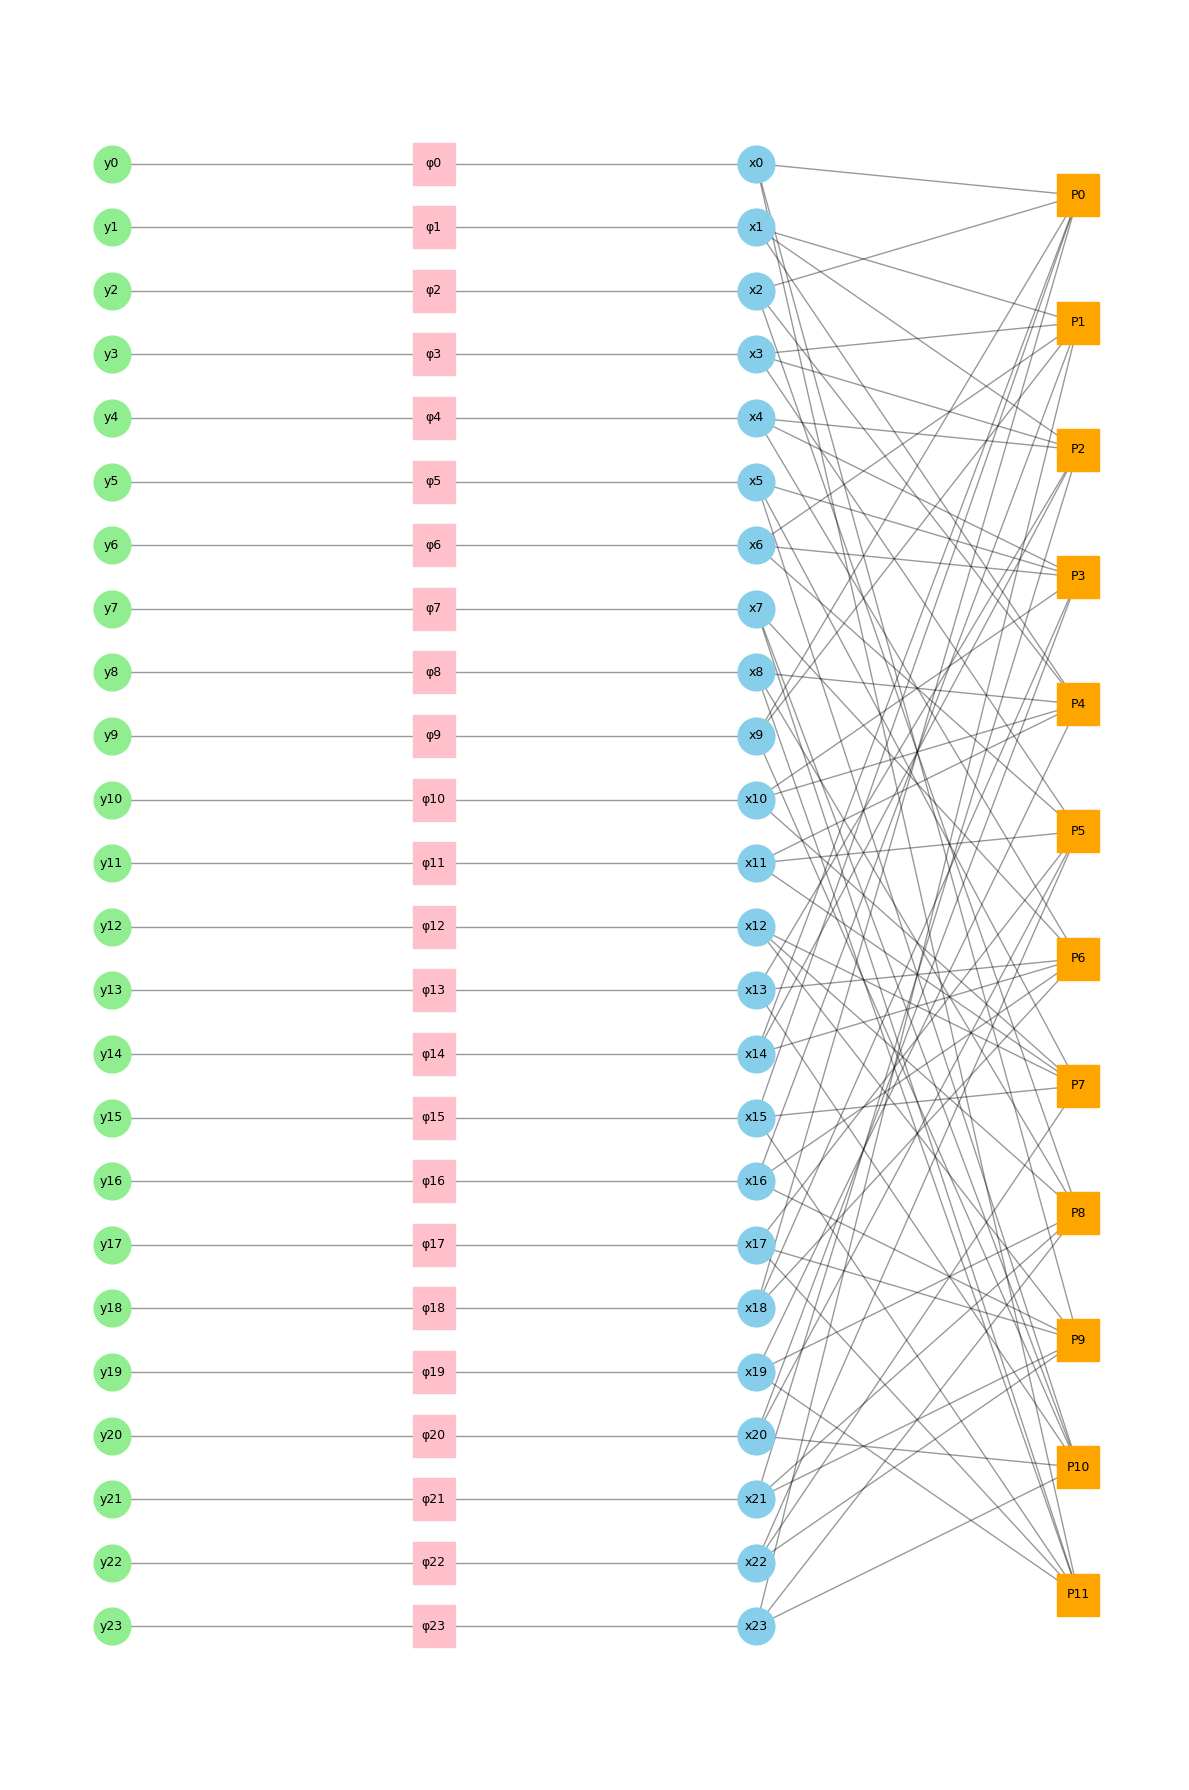

In [ ]:
def visualize_factor_graph(G: FactorGraph, max_nodes: int = 200):
    """
    Visualize an LDPC factor graph with columns:
      y vars -> channel factors -> x vars -> parity-check factors
    Factors are labeled for clarity.
    """
    # Convert FactorGraph to networkx
    Hnx = nx.Graph()

    # Add nodes and edges
    for node in G.nodes():
        Hnx.add_node(node)

    for factor in G.get_factors():
        for var in factor.scope():
            Hnx.add_edge(factor, var)

    if Hnx.number_of_nodes() > max_nodes:
        print(f"Graph too large to display (> {max_nodes} nodes).")
        return

    # Separate node types
    x_vars = [v for v in G.nodes() if isinstance(v, str) and v.startswith("x")]
    y_vars = [v for v in G.nodes() if isinstance(v, str) and v.startswith("y")]
    parity_factors = [f for f in G.get_factors() if len(f.scope()) > 2]
    channel_factors = [f for f in G.get_factors() if len(f.scope()) == 2 and any(v.startswith("y") for v in f.scope())]

    # Column positions
    col_positions = {"y": 0, "channel": 1, "x": 2, "parity": 3}

    # Increased gap to prevent nodes from overlapping vertically
    vertical_gap = 2.5

    # Tall figure size to allow the 24 nodes to breathe
    plt.figure(figsize=(12, 18))

    # Assign positions (spread vertically)
    pos = {}
    for i, v in enumerate(y_vars):
        pos[v] = (col_positions["y"], -i * vertical_gap)

    for i, f in enumerate(channel_factors):
        pos[f] = (col_positions["channel"], -i * vertical_gap)

    for i, v in enumerate(x_vars):
        pos[v] = (col_positions["x"], -i * vertical_gap)

    # Center parity factors relative to the height of the x variables
    # This prevents them from bunching up at the top
    if len(parity_factors) > 0:
        parity_spacing = (len(x_vars) * vertical_gap) / len(parity_factors)
        for i, f in enumerate(parity_factors):
            # Offset slightly to align with the middle of the connections
            pos[f] = (col_positions["parity"], -i * parity_spacing - (vertical_gap / 2))

    # Draw nodes with bigger size
    nx.draw_networkx_nodes(Hnx, pos, nodelist=x_vars, node_color="skyblue", node_size=700)
    nx.draw_networkx_nodes(Hnx, pos, nodelist=y_vars, node_color="lightgreen", node_size=700)
    nx.draw_networkx_nodes(Hnx, pos, nodelist=parity_factors, node_color="orange", node_shape="s", node_size=900)
    nx.draw_networkx_nodes(Hnx, pos, nodelist=channel_factors, node_color="pink", node_shape="s", node_size=900)

    # Draw edges with transparency so you can see individual lines better
    nx.draw_networkx_edges(Hnx, pos, width=1.0, alpha=0.4)

    # Create labels for nodes
    labels = {}
    for v in x_vars + y_vars:
        labels[v] = v

    for i, f in enumerate(parity_factors):
        labels[f] = f"P{i}"

    for i, f in enumerate(channel_factors):
        labels[f] = f"φ{i}"

    nx.draw_networkx_labels(Hnx, pos, labels, font_size=9)

    plt.axis('off')
    plt.tight_layout()
    plt.show()
H = generate_regular_ldpc_H(N=24, j=3, k=6, seed=1)
G = build_ldpc_factor_graph(H, f=0.8)
visualize_factor_graph(G)

## 6. Treewidth and Inference Complexity

Exact inference in graphical models can become computationally expensive when the graph has large treewidth.

To study this, we construct the primal graph over the transmitted bit variables. In this graph, two variables are connected if they appear together in at least one parity-check factor.

The approximate treewidth of this primal graph provides insight into the difficulty of exact inference.

As the LDPC block length $N$ increases, the treewidth generally increases as well, making exact inference less practical. This motivates the use of approximate methods such as loopy belief propagation.

In [ ]:
def ldpc_primal_graph_on_x(G):
    """Build the primal graph on x-variables only.

    Nodes: x0..x{N-1}
    Edge between xi and xj if some parity-check factor contains both.
    """
    P = nx.Graph()

    # x-variable nodes only
    x_vars = [v for v in G.nodes()
          if isinstance(v, str) and v.startswith("x")]

    P.add_nodes_from(x_vars)

    # parity-check factors are the ones whose scope contains only x's
    for factor in G.get_factors():
        scope = factor.scope()

        # keep only x variables in this factor
        xs = [v for v in scope if isinstance(v, str) and v.startswith("x")]

        # parity checks should involve >= 2 x vars
        if len(xs) >= 2:
            # connect all pairs (clique)
            for i in range(len(xs)):
                for j in range(i + 1, len(xs)):
                    P.add_edge(xs[i], xs[j])

    return P


def treewidth_scaling_experiment(N_list, j, k, f=0.08, seed0=0):
    """Estimate treewidth scaling for increasing block lengths N.

    Returns a list of tuples (N, estimated_treewidth, num_edges).
    """
    results = []

    for t, N in enumerate(N_list):
        H = generate_regular_ldpc_H(N=N, j=j, k=k, seed=seed0 + t) #seed changes to not produce highly correlated mztrixes
        G = build_ldpc_factor_graph(H, f=f)

        P = ldpc_primal_graph_on_x(G)
        tw, _ = treewidth_min_fill_in(P)

        results.append((N, tw, P.number_of_edges()))

    return results

N_list = [12, 18, 24, 30, 36, 42, 50]
j, k = 3, 6
tw_results = treewidth_scaling_experiment(N_list, j=j, k=k, f=0.08, seed0=0)
tw_results

''' inference becomes intractable around treewidth=20 (2**20 is approx. a million)'''

[(12, 9, 60),
 (18, 12, 106),
 (24, 14, 154),
 (30, 18, 198),
 (36, 20, 248),
 (42, 25, 293),
 (50, 30, 351)]

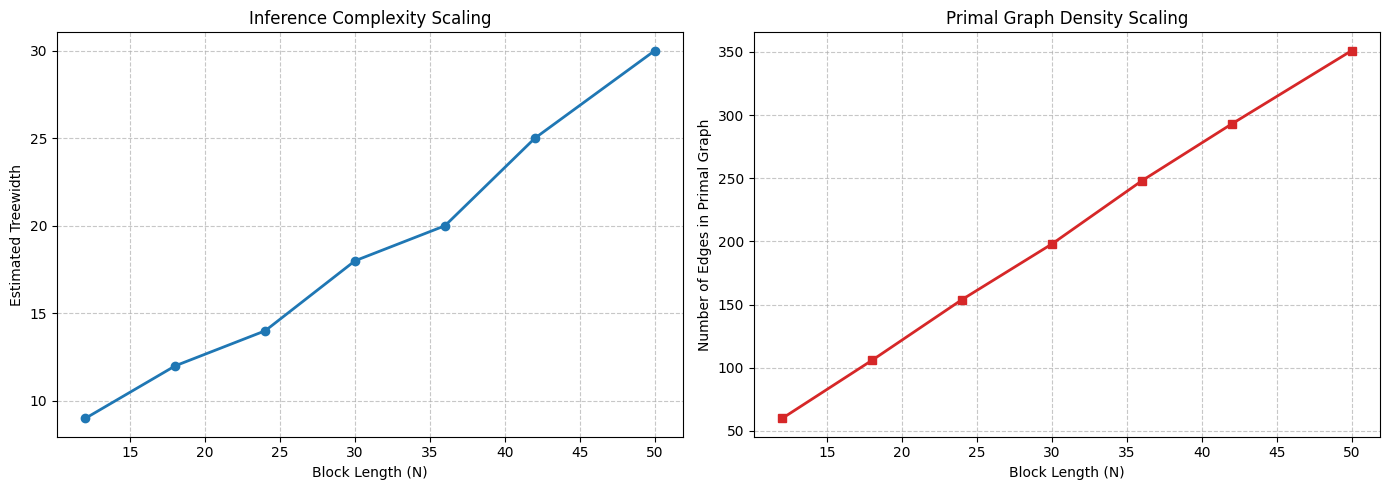

In [ ]:
def plot_treewidth_scaling(results):
    """
    Plots the results of the treewidth scaling experiment.
    Input: List of tuples (N, estimated_treewidth, num_edges)
    """
    # Unpack the results
    ns = [r[0] for r in results]
    tws = [r[1] for r in results]
    edges = [r[2] for r in results]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Treewidth vs N
    ax1.plot(ns, tws, 'o-', color='tab:blue', linewidth=2)
    ax1.set_xlabel('Block Length (N)')
    ax1.set_ylabel('Estimated Treewidth')
    ax1.set_title('Inference Complexity Scaling')
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Plot 2: Number of Edges in Primal Graph vs N
    ax2.plot(ns, edges, 's-', color='tab:red', linewidth=2)
    ax2.set_xlabel('Block Length (N)')
    ax2.set_ylabel('Number of Edges in Primal Graph')
    ax2.set_title('Primal Graph Density Scaling')
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_treewidth_scaling(tw_results)

## Conclusion

This project constructed a factor graph representation of a regular LDPC code using a sparse parity-check matrix.

The analysis showed how parity-check constraints and noisy channel observations can be represented as factors in a probabilistic graphical model. This formulation provides the foundation for LDPC decoding through inference algorithms.

The project also highlighted the computational challenge of exact inference. By studying the primal graph and estimating treewidth, we observed that inference complexity increases with the size and connectivity of the LDPC code.

Overall, this notebook connects three important ideas:

- error-correcting codes,
- probabilistic graphical models,
- and computational complexity of inference.

This representation will be used as the basis for LDPC decoding with loopy belief propagation in the next project.